# Time Series With Pandas Code Along

import pandas first!

In [1]:
import pandas as pd

import the csv file and check the head

In [2]:
uk = pd.read_csv('uk_temp.csv')

check the types of your data

In [3]:
display(uk.info())
uk.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 1354 entries, 0 to 1353
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dt                  1354 non-null   str    
 1   AverageTemperature  1353 non-null   float64
dtypes: float64(1), str(1)
memory usage: 21.3 KB


None

,dt,AverageTemperature
0,1935-10-01,8.522
1,1977-08-01,13.688
2,1965-03-01,5.074


use pd.to_datetime() to convert the date column to correct type

In [4]:
uk['dt'] = pd.to_datetime(uk['dt'])
uk.dtypes

dt                    datetime64[us]
AverageTemperature           float64
dtype: object

Make the date column the index

In [5]:
uk = uk.set_index('dt')
uk.head()

,AverageTemperature
dt,
1935-10-01,8.522
1977-08-01,13.688
1965-03-01,5.074
1937-09-01,12.122
1935-11-01,6.328


sort the index to ascending order using .sort_index() and ascending=True

In [6]:
uk = uk.sort_index(ascending=True)
uk.head(3)

,AverageTemperature
dt,
1900-02-01,2.363
1900-03-01,3.601
1900-04-01,7.374


check the tail of the data

In [7]:
uk.tail()

,AverageTemperature
dt,
2013-05-01,9.605
2013-06-01,12.826
2013-07-01,16.260
2013-08-01,15.022
2013-09-01,NaN


great, the data is sorted in ascending order and the date column is the index. Now we can do some time series analysis on this data.

# Visualising Time Series Data

#### Plot a time series with a `datetime` index using `.plot()`

Set plotting configurations

<Axes: xlabel='dt'>

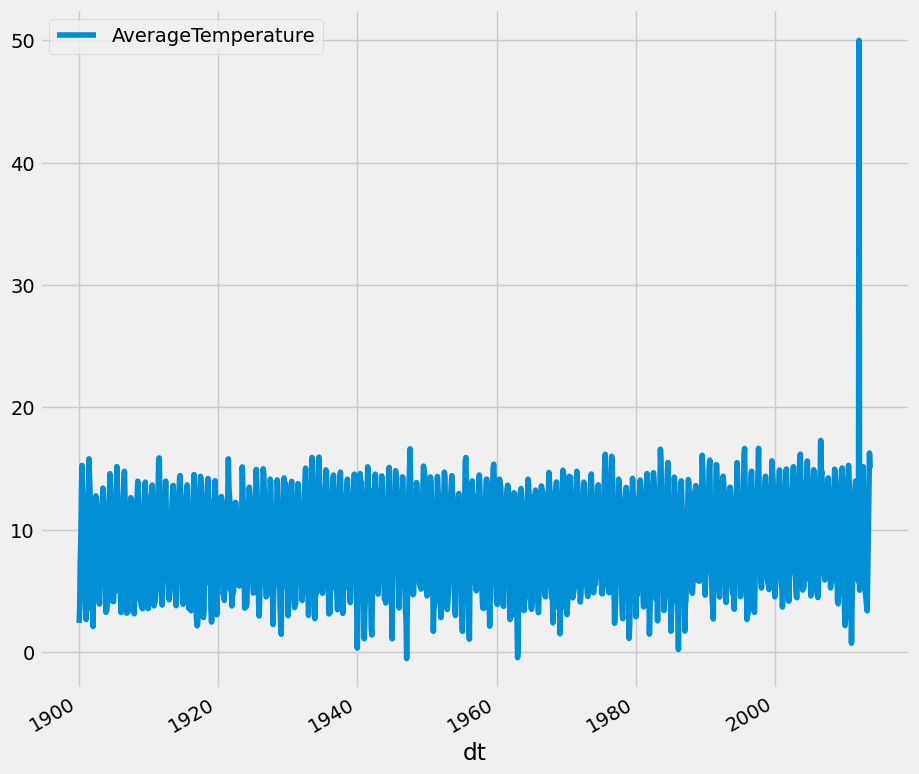

In [8]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (10,10)
uk.plot()

### filtering time series

plot the tempuratures for the year on your birthday

<Axes: xlabel='dt'>

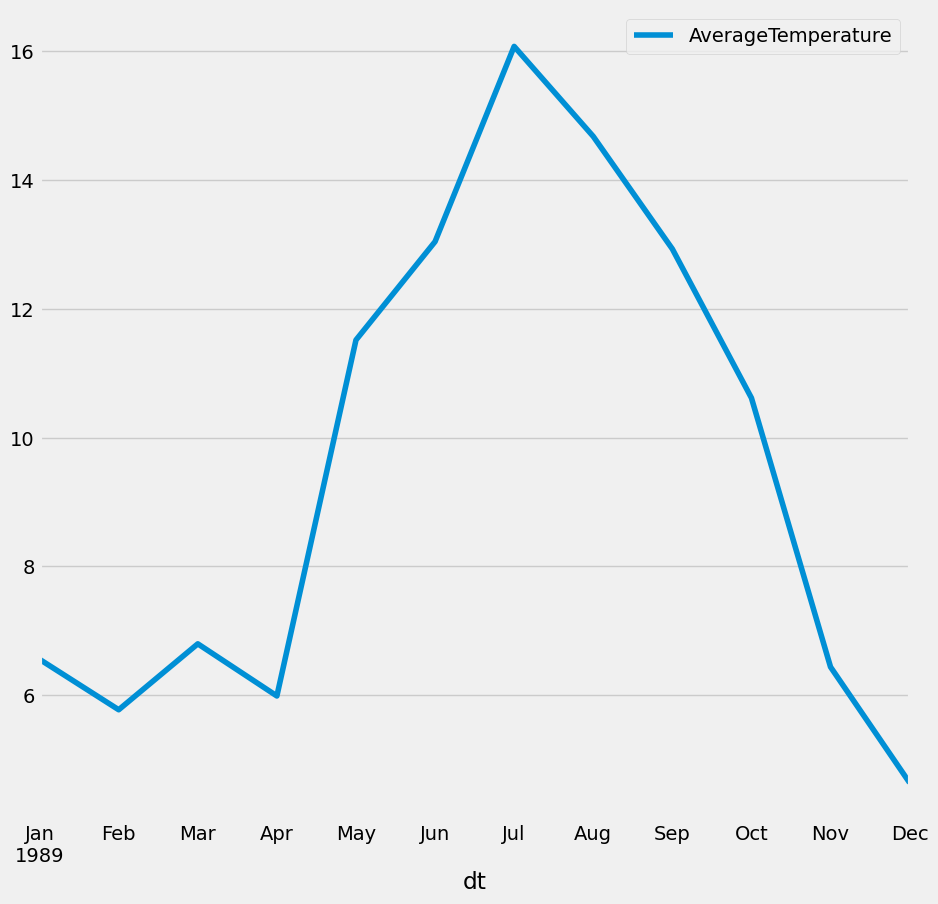

In [9]:
uk.loc['1989'].plot()

show monthly data for year from 1995 to 2000

<Axes: xlabel='dt'>

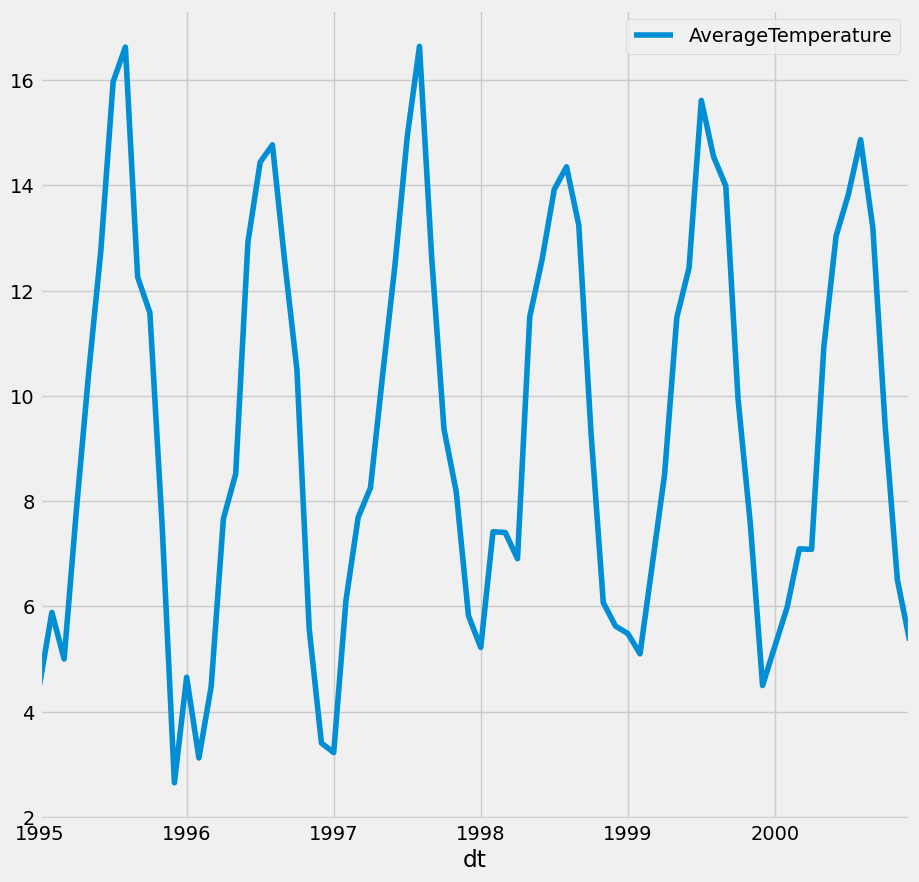

In [10]:
uk.loc['1995':'2000'].plot()

show the times series for your birthday month across all years

<Axes: xlabel='dt'>

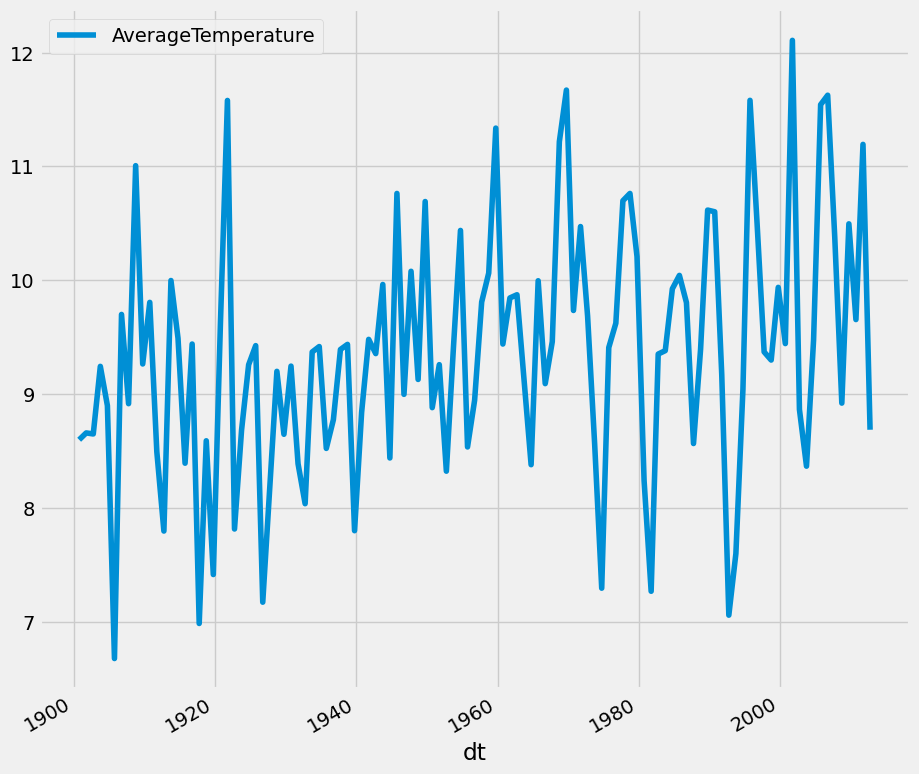

In [11]:
uk[uk.index.month_name() == 'October'].plot()

apply some known `methods` to explore the time series data, such as `info()` and  `describe()`

.info()

In [12]:
uk.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1354 entries, 1900-02-01 to 2013-09-01
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AverageTemperature  1353 non-null   float64
dtypes: float64(1)
memory usage: 53.4 KB


.describe()

In [13]:
uk.describe()

,AverageTemperature
count,1353.000000
mean,8.813409
std,4.023819
min,-0.546000
25%,5.525000
50%,8.432000
75%,12.498000
max,50.000000


the range in days between the defined minimum and maximum values

In [14]:
uk.index.max() - uk.index.min()

Timedelta('41485 days 00:00:00')

### observations

 - outlier values at 50

### Outliers  in time series data

filter the data to show outliers hint surface tempurature ever recorded was 48.4 degrees

In [15]:
uk[uk['AverageTemperature'] > 48.4]

,AverageTemperature
dt,
2012-01-01,50.0


drop the outlier and check the description again

In [16]:
uk.drop('2012-01-01').describe()

,AverageTemperature
count,1352.000000
mean,8.782945
std,3.866078
min,-0.546000
25%,5.521500
50%,8.427000
75%,12.486750
max,17.285000


check the values near the outliers 2 above and 2 below

In [17]:
uk.loc['2011-11-01': '2012-03-01']

,AverageTemperature
dt,
2011-11-01,9.319
2011-12-01,5.750
2012-01-01,50.000
2012-02-01,5.040
2012-03-01,8.098


check the mean of the time period

In [18]:
uk[uk.index.month == 1].mean()

AverageTemperature    4.552721
dtype: float64

replace the outlier with previous value in the series

In [19]:
uk.loc['2012-01-01'] = uk.loc['2011-12-01']
uk.loc['2011-11-01': '2012-03-01']

,AverageTemperature
dt,
2011-11-01,9.319
2011-12-01,5.750
2012-01-01,5.750
2012-02-01,5.040
2012-03-01,8.098


check the result

#### Handling missing dates in a `datetime` index with `.asfreq()`

In [20]:
uk.shape

(1354, 1)

In [21]:
uk = uk.asfreq('MS')

apply the 'MS' frequency to the data

In [22]:
uk.shape

(1364, 1)

check the shape of the data before and after applying the  frequency

check how many missing dates there are in the data

In [23]:
uk.isna().sum()

AverageTemperature    11
dtype: int64

lets check the missing dates

In [24]:
uk[uk['AverageTemperature'].isna()]

,AverageTemperature
dt,
1901-05-01,NaN
1904-01-01,NaN
1924-04-01,NaN
1925-01-01,NaN
1925-09-01,NaN
1927-10-01,NaN
1934-12-01,NaN
1941-05-01,NaN
1955-11-01,NaN


let check the count for missing per year

In [25]:
uk[uk['AverageTemperature'].isna()].index.year.value_counts()

dt
1925    2
1901    1
1904    1
1924    1
1927    1
1934    1
1941    1
1955    1
1963    1
2013    1
Name: count, dtype: int64

lets forward fill the missing values and check the count again

In [26]:
uk['AverageTemperature'] = uk['AverageTemperature'].ffill()
uk.isna().sum()

AverageTemperature    0
dtype: int64

### changing the frequency of your time series data


- change the time series from monthly to yearly and plot it, using Y then YS what happens?

#### Resample a time series in `pandas` with the `.resample()` method


resample your with the mean

<Axes: xlabel='dt'>

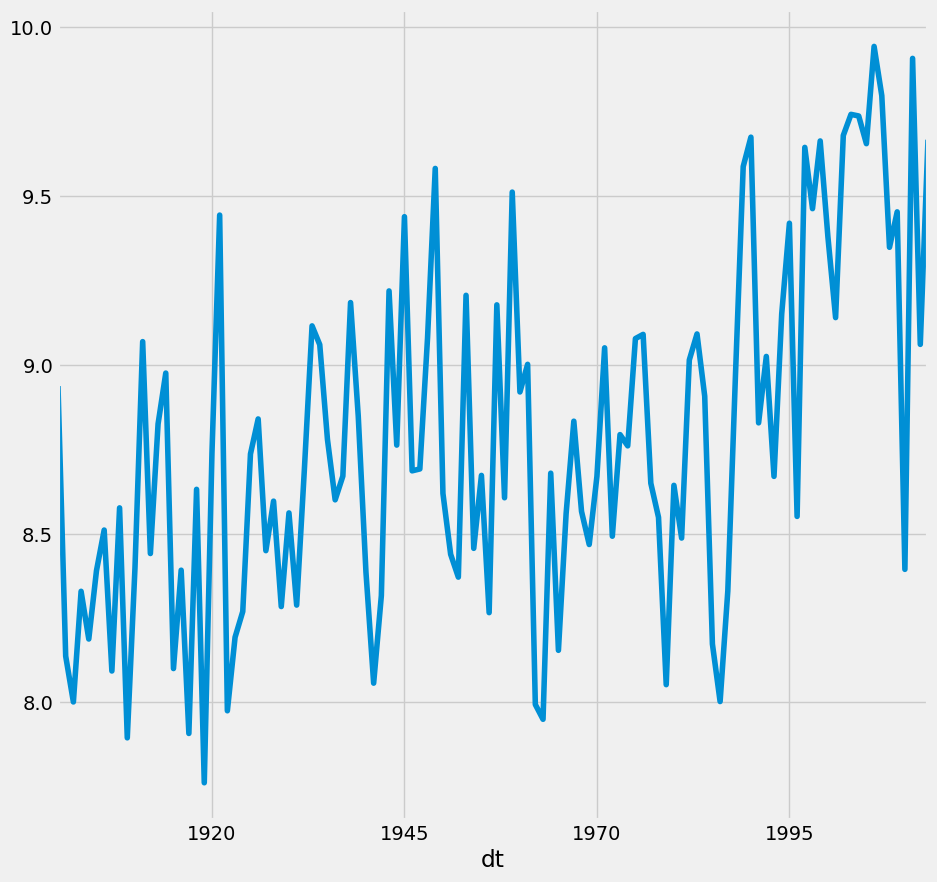

In [27]:
uk.resample('1YE')['AverageTemperature'].mean().plot()

#### Perform a rolling average on time series data with `.rolling()`


- do a rolling average with mean
- hint: do consider that we have monthly data

<Axes: xlabel='dt'>

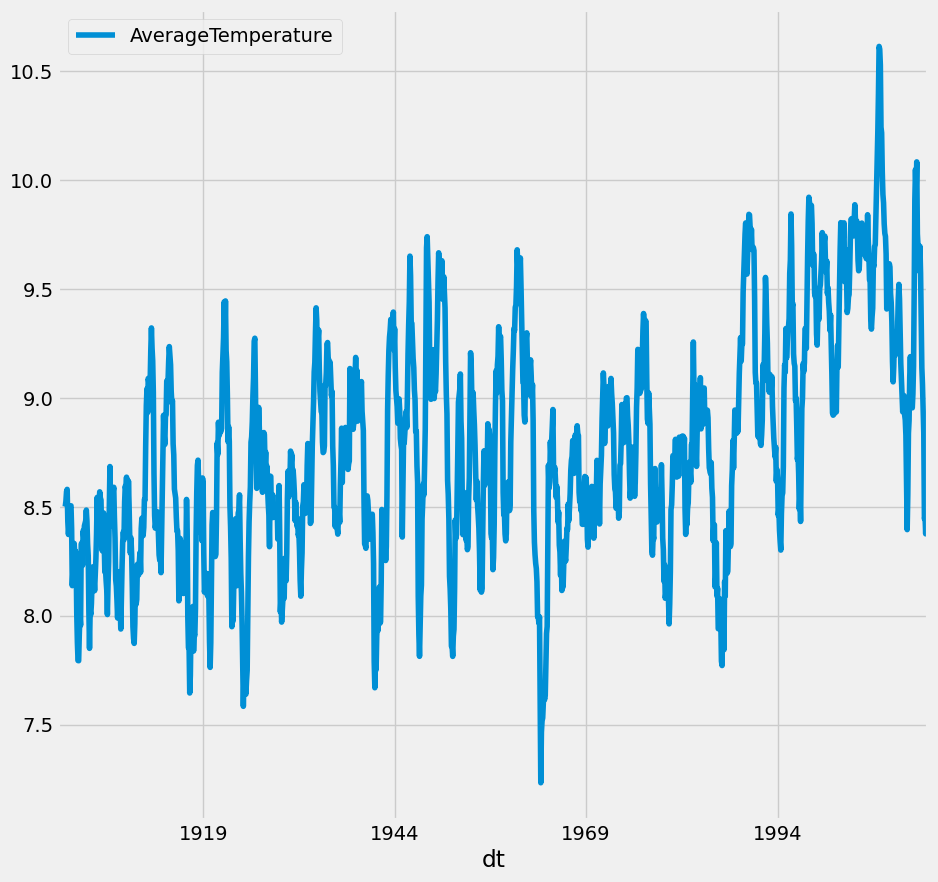

In [32]:
uk.rolling(window = 12).mean().plot()